In [7]:
# Import required libraries
import pandas as pd
import numpy as np
from neo4j import GraphDatabase
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from rich import print
import os

Start server

bash neo4j/setup_neo4j.sh 

python neo4j/create_neo4j_graph.py --clear --queries --json-dir "/home/sga/Code/FAIRFluids/Workflows/paper_outputs"


In [8]:
#Connect to server
#Run query
#Get results
#Disconnect from server


# Neo4j connection parameters
NEO4J_URI = "bolt://localhost:7687"
NEO4J_USER = "neo4j"
NEO4J_PASSWORD = "password"  # Update with your password

# Connect to Neo4j
driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))

def test_connection():
    """Test the Neo4j connection"""
    with driver.session() as session:
        result = session.run("RETURN 1 as test")
        record = result.single()
        print(f"✅ Connected to Neo4j! Test result: {record['test']}")

test_connection()

✅ Connected to Neo4j! Test result: 1

In [9]:
# Define the Cypher query
# Find ONLY pure water (water mole fraction = 1)
# Water = 962
# Based on Neo4j structure: Experiments connect to Compounds via HAS_COMPOUND (with mole_fraction on edge),
# to Properties via HAS_PROPERTY (with value/uncertainty on edge), and to Parameters via HAS_PARAMETER
query = """
// Match experiments with compounds
MATCH (e:Experiment)-[rcomp:HAS_COMPOUND]->(c:Compound)
WITH e, collect(DISTINCT {
    pubChemID: c.pubChemID,
    compoundID: c.compoundID,
    commonName: c.commonName,
    mole_fraction: rcomp.mole_fraction
}) as compounds

// Filter for experiments that have water with mole fraction = 1
WHERE ANY(c IN compounds WHERE c.pubChemID = 962 AND c.mole_fraction = 1)

// Check for water mole fraction = 1 via HAS_PARAMETER as well
OPTIONAL MATCH (e)-[rparamWater:HAS_PARAMETER]->(paramWater:Parameter)
WHERE toLower(paramWater.parameter) CONTAINS 'mole fraction' AND
      (toLower(paramWater.parameter) CONTAINS 'water' OR 
       paramWater.pubChemID = 962 OR
       toLower(paramWater.parameterID) CONTAINS 'water')

WITH e, compounds,
     [c IN compounds WHERE c.pubChemID = 962 | c.mole_fraction][0] as mole_fraction_water_compound,
     rparamWater.value as mole_fraction_water_param

WHERE (mole_fraction_water_compound = 1 OR mole_fraction_water_param = 1)

// Get temperature from HAS_PARAMETER relationship or from Experiment properties
OPTIONAL MATCH (e)-[rparam:HAS_PARAMETER]->(param:Parameter)
WHERE toLower(param.parameter) CONTAINS 'temperature'
   OR toLower(param.parameterID) CONTAINS 'temperature'
WITH e, compounds, mole_fraction_water_compound, mole_fraction_water_param,
     COALESCE(mole_fraction_water_compound, mole_fraction_water_param, 1) as mole_fraction_water,
     COALESCE(
       [r IN collect(DISTINCT rparam.value) WHERE r IS NOT NULL][0],
       e.param_temperature
     ) as temperature

// Match properties (especially viscosity) via HAS_PROPERTY relationship
OPTIONAL MATCH (e)-[rprop:HAS_PROPERTY]->(p:Property)
WHERE p.propertyType = 'viscosity' OR toLower(p.propertyType) CONTAINS 'viscosity'

// Get viscosity from Experiment properties as fallback
WITH e, compounds, mole_fraction_water, temperature,
     COALESCE(rprop.value, e.prop_viscosity) as property_value,
     rprop.uncertainty as property_uncertainty,
     COALESCE(p.propertyType, 'viscosity') as property_type
WHERE property_value IS NOT NULL AND temperature IS NOT NULL

// Return one row per experiment
RETURN DISTINCT
       e.experiment_id as experiment_id,
       property_type,
       property_value,
       property_uncertainty,
       null as mole_fraction_glycerol,
       mole_fraction_water as mole_fraction_water,
       null as mole_fraction_cholinechloride,
       temperature,
       e.method as method,
       e.source_file as source_file,
       e.source_doi as source_doi
ORDER BY e.experiment_id, property_type
"""

# Execute query and convert to DataFrame
with driver.session() as session:
    result = session.run(query)
    records = [dict(record) for record in result]

water_df = pd.DataFrame(records)

print(f"Retrieved {len(water_df)} records")
print(f"\nFirst few rows:")
water_df

Retrieved 14 records

First few rows:

,experiment_id,property_type,property_value,property_uncertainty,mole_fraction_glycerol,mole_fraction_water,mole_fraction_cholinechloride,temperature,method,source_file,source_doi
0,04303413-6bb9-42ac-b6fc-7719729a8fdc,viscosity,0.000331,0.000002,None,1.0,None,363.15,measured,Xu_Glycerol_Water.json,10.1016/j.fluid.2014.01.028
1,0b84e36d-ec7c-4fb1-8495-be4fa84ad99e,viscosity,0.000477,0.000002,None,1.0,None,333.15,measured,Xu_Glycerol_Water.json,10.1016/j.fluid.2014.01.028
2,13ff5c56-ea5e-4abd-ad7b-89afe6e6b1f5,viscosity,0.000386,0.000002,None,1.0,None,353.15,measured,Xu_Glycerol_Water.json,10.1016/j.fluid.2014.01.028
3,15066af3-838d-4b8e-b80c-bc9ab630296a,viscosity,0.000984,0.000005,None,1.0,None,293.15,measured,Xu_Glycerol_Water.json,10.1016/j.fluid.2014.01.028
4,25cf85fb-f720-45b8-9488-7b8f57112fc5,viscosity,0.000549,0.000003,None,1.0,None,323.15,measured,Xu_Glycerol_Water.json,10.1016/j.fluid.2014.01.028
5,39b63fbb-680a-48c1-b3b8-d967ed37d6dc,viscosity,0.000413,0.000002,None,1.0,None,333.15,simulated,spera_et_al_fpe_592_2025_114324.json,10.1016/j.fluid.2024.114324
6,5546497f-309a-44a8-8fe3-f367ffbeff24,viscosity,0.001274,0.000006,None,1.0,None,283.15,measured,Xu_Glycerol_Water.json,10.1016/j.fluid.2014.01.028
7,7a6a3d5d-6f96-4c21-9d1a-47026fbd132f,viscosity,0.000557,0.000005,None,1.0,None,313.15,simulated,spera_et_al_fpe_592_2025_114324.json,10.1016/j.fluid.2024.114324
8,875bd6be-feb0-4169-987f-74fcaa03800b,viscosity,0.000791,0.000004,None,1.0,None,303.15,measured,Xu_Glycerol_Water.json,10.1016/j.fluid.2014.01.028
9,c5860247-d716-4554-a731-57aa042e3520,viscosity,0.000359,0.000001,None,1.0,None,343.15,simulated,spera_et_al_fpe_592_2025_114324.json,10.1016/j.fluid.2024.114324


In [10]:
# Define the Cypher query
# Find ONLY Glycerol + Choline chloride (no water) and only those with 
# "Solvent: Amount ratio of component to other component of binary solvent == 2"
# Glycerol = 753, Choline chloride = 6209, Water = 962
# Based on Neo4j structure: Experiments connect to Compounds via HAS_COMPOUND (with mole_fraction on edge),
# to Properties via HAS_PROPERTY (with value/uncertainty on edge), and to Parameters via HAS_PARAMETER
query = """
// Only Glycerol + Choline chloride, exactly 2 compounds, no water
MATCH (e:Experiment)-[rcomp:HAS_COMPOUND]->(c:Compound)
WITH e, collect(DISTINCT {
    pubChemID: c.pubChemID,
    compoundID: c.compoundID,
    commonName: c.commonName,
    mole_fraction: rcomp.mole_fraction
}) as compounds
WHERE size(compounds) = 2
  AND ANY(c IN compounds WHERE c.pubChemID = 753)
  AND ANY(c IN compounds WHERE c.pubChemID = 6209)
  AND NOT ANY(c IN compounds WHERE c.pubChemID = 962)

// Now filter for Amount ratio == 2 via HAS_PARAMETER
OPTIONAL MATCH (e)-[rparamRatio:HAS_PARAMETER]->(paramRatio:Parameter)
WHERE toLower(paramRatio.parameter) CONTAINS 'solvent' AND
      toLower(paramRatio.parameter) CONTAINS 'amount ratio'
WITH e, compounds, rparamRatio, paramRatio,
     [c IN compounds WHERE c.pubChemID = 753 | c.mole_fraction][0] as mole_fraction_glycerol,  // Glycerol
     COALESCE([c IN compounds WHERE c.pubChemID = 962 | c.mole_fraction][0], 0) as mole_fraction_water,  // Water (will be 0)
     [c IN compounds WHERE c.pubChemID = 6209 | c.mole_fraction][0] as mole_fraction_cholinechloride  // Choline chloride

WHERE rparamRatio.value = 2

// Step 3: Get temperature from HAS_PARAMETER relationship or from Experiment properties
OPTIONAL MATCH (e)-[rparam:HAS_PARAMETER]->(param:Parameter)
WHERE toLower(param.parameter) CONTAINS 'temperature'
   OR toLower(param.parameterID) CONTAINS 'temperature'
WITH e, compounds, mole_fraction_glycerol, mole_fraction_water, mole_fraction_cholinechloride,
     COALESCE(
       [r IN collect(DISTINCT rparam.value) WHERE r IS NOT NULL][0],
       e.param_temperature
     ) as temperature

// Step 4: Match properties (especially viscosity) via HAS_PROPERTY relationship
OPTIONAL MATCH (e)-[rprop:HAS_PROPERTY]->(p:Property)
WHERE p.propertyType = 'viscosity' OR toLower(p.propertyType) CONTAINS 'viscosity'

// Step 5: Also get viscosity from Experiment properties as fallback
WITH e, compounds, mole_fraction_glycerol, mole_fraction_water, mole_fraction_cholinechloride, temperature,
     COALESCE(rprop.value, e.prop_viscosity) as property_value,
     rprop.uncertainty as property_uncertainty,
     COALESCE(p.propertyType, 'viscosity') as property_type
WHERE property_value IS NOT NULL AND temperature IS NOT NULL

// Step 6: Return one row per experiment (not per compound)
RETURN DISTINCT
       e.experiment_id as experiment_id,
       property_type,
       property_value,
       property_uncertainty,
       mole_fraction_glycerol,
       mole_fraction_water,
       mole_fraction_cholinechloride,
       temperature,
       e.method as method,
       e.source_file as source_file,
       e.source_doi as source_doi
ORDER BY e.experiment_id, property_type
"""

# Execute query and convert to DataFrame
with driver.session() as session:
    result = session.run(query)
    records = [dict(record) for record in result]

des_pure_df = pd.DataFrame(records)

print(f"Retrieved {len(des_pure_df)} records")
print(f"\nFirst few rows:")
des_pure_df

Retrieved 62 records

First few rows:

,experiment_id,property_type,property_value,property_uncertainty,mole_fraction_glycerol,mole_fraction_water,mole_fraction_cholinechloride,temperature,method,source_file,source_doi
0,0211680d-87a7-44a4-a5a4-e3970990bee4,viscosity,0.113800,0.002276,0.666667,0,0.333333,315.650,measured,Xu_Glycerol_Water.json,10.1016/j.jct.2018.07.031
1,12bf784b-1496-4798-9f50-2a1091130712,viscosity,0.062060,0.001241,0.666667,0,0.333333,328.150,measured,Xu_Glycerol_Water.json,10.1016/j.jct.2018.07.031
2,1341a5f9-9c59-4680-9a52-7fc54e56e231,viscosity,0.072517,NaN,0.666667,0,0.333333,327.826,measured,Xu_Glycerol_Water.json,10.1016/j.molliq.2015.11.032
3,17ef9c6e-eed6-4e5f-9b03-cfeca1e58f0a,viscosity,0.319700,0.006394,0.666667,0,0.333333,298.150,measured,Xu_Glycerol_Water.json,10.1016/j.jct.2018.07.031
4,1903429f-f1ad-45b5-a281-d7638e4706b4,viscosity,0.064000,0.001920,0.666667,0,0.333333,323.150,measured,Xu_Glycerol_Water.json,10.1039/c0gc00395f
...,...,...,...,...,...,...,...,...,...,...,...
57,ead4eb49-3061-49df-85d8-59b905b12010,viscosity,0.053812,0.000269,0.666667,0,0.333333,333.150,measured,Xu_Glycerol_Water.json,10.1016/j.fluid.2014.01.028
58,ec1f889d-c6cf-4541-9b5a-069bc5138bf1,viscosity,0.171600,0.003432,0.666667,0,0.333333,308.150,measured,Xu_Glycerol_Water.json,10.1016/j.jct.2018.07.031
59,f1588f66-baec-43a2-abf4-09d6777d4d07,viscosity,0.019587,0.000098,0.666667,0,0.333333,363.150,measured,Xu_Glycerol_Water.json,10.1016/j.fluid.2014.01.028
60,f37a3bbe-946d-475a-9f47-ef79e2e031c2,viscosity,0.543700,0.010874,0.666667,0,0.333333,290.650,measured,Xu_Glycerol_Water.json,10.1016/j.jct.2018.07.031


In [11]:
# Define the Cypher query
# Find experiments with Glycerol + Choline chloride + Water (all 3 compounds) and only those with 
# "Solvent: Amount ratio of component to other component of binary solvent == 2"
# Glycerol = 753, Choline chloride = 6209, Water = 962
# Based on Neo4j structure: Experiments connect to Compounds via HAS_COMPOUND (with mole_fraction on edge),
# to Properties via HAS_PROPERTY (with value/uncertainty on edge), and to Parameters via HAS_PARAMETER
query = """
// Find experiments with exactly Glycerol + Choline chloride + Water (all 3 compounds)
MATCH (e:Experiment)-[rcomp:HAS_COMPOUND]->(c:Compound)
WITH e, collect(DISTINCT {
    pubChemID: c.pubChemID,
    compoundID: c.compoundID,
    commonName: c.commonName,
    mole_fraction: rcomp.mole_fraction
}) as compounds
WHERE size(compounds) = 3
  AND ANY(c IN compounds WHERE c.pubChemID = 753)   // Glycerol
  AND ANY(c IN compounds WHERE c.pubChemID = 6209)  // Choline chloride
  AND ANY(c IN compounds WHERE c.pubChemID = 962)   // Water

// Now filter for Amount ratio == 2 via HAS_PARAMETER
OPTIONAL MATCH (e)-[rparamRatio:HAS_PARAMETER]->(paramRatio:Parameter)
WHERE toLower(paramRatio.parameter) CONTAINS 'solvent' AND
      toLower(paramRatio.parameter) CONTAINS 'amount ratio'
WITH e, compounds, rparamRatio, paramRatio,
     [c IN compounds WHERE c.pubChemID = 753 | c.mole_fraction][0] as mole_fraction_glycerol,  // Glycerol
     [c IN compounds WHERE c.pubChemID = 962 | c.mole_fraction][0] as mole_fraction_water,  // Water
     [c IN compounds WHERE c.pubChemID = 6209 | c.mole_fraction][0] as mole_fraction_cholinechloride  // Choline chloride

WHERE rparamRatio.value = 2

// Step 3: Get temperature from HAS_PARAMETER relationship or from Experiment properties
OPTIONAL MATCH (e)-[rparam:HAS_PARAMETER]->(param:Parameter)
WHERE toLower(param.parameter) CONTAINS 'temperature'
   OR toLower(param.parameterID) CONTAINS 'temperature'
WITH e, compounds, mole_fraction_glycerol, mole_fraction_water, mole_fraction_cholinechloride,
     COALESCE(
       [r IN collect(DISTINCT rparam.value) WHERE r IS NOT NULL][0],
       e.param_temperature
     ) as temperature

// Step 4: Match properties (especially viscosity) via HAS_PROPERTY relationship
OPTIONAL MATCH (e)-[rprop:HAS_PROPERTY]->(p:Property)
WHERE p.propertyType = 'viscosity' OR toLower(p.propertyType) CONTAINS 'viscosity'

// Step 5: Also get viscosity from Experiment properties as fallback
WITH e, compounds, mole_fraction_glycerol, mole_fraction_water, mole_fraction_cholinechloride, temperature,
     COALESCE(rprop.value, e.prop_viscosity) as property_value,
     rprop.uncertainty as property_uncertainty,
     COALESCE(p.propertyType, 'viscosity') as property_type
WHERE property_value IS NOT NULL AND temperature IS NOT NULL

// Step 6: Return one row per experiment (not per compound)
RETURN DISTINCT
       e.experiment_id as experiment_id,
       property_type,
       property_value,
       property_uncertainty,
       mole_fraction_glycerol,
       mole_fraction_water,
       mole_fraction_cholinechloride,
       temperature,
       e.method as method,
       e.source_file as source_file,
       e.source_doi as source_doi
ORDER BY e.experiment_id, property_type
"""

# Execute query and convert to DataFrame
with driver.session() as session:
    result = session.run(query)
    records = [dict(record) for record in result]

des_water_df = pd.DataFrame(records).dropna()

print(f"Retrieved {len(des_water_df)} records")
print(f"\nFirst few rows:")
des_water_df

Retrieved 168 records

First few rows:

,experiment_id,property_type,property_value,property_uncertainty,mole_fraction_glycerol,mole_fraction_water,mole_fraction_cholinechloride,temperature,method,source_file,source_doi
0,01ecd11d-f94e-4dd0-8d29-76e0d796c5f7,viscosity,0.177962,0.000890,0.398533,0.4022,0.199267,283.15,measured,Xu_Glycerol_Water.json,10.1016/j.fluid.2014.01.028
1,02bc464f-b26b-4bde-8b52-4fd7a59a9e11,viscosity,0.002020,0.000010,0.095067,0.8574,0.047533,323.15,measured,Xu_Glycerol_Water.json,10.1016/j.fluid.2014.01.028
2,048f2768-bf16-4368-87bd-b1e5d0077372,viscosity,0.001574,0.000008,0.044333,0.9335,0.022167,303.15,measured,Xu_Glycerol_Water.json,10.1016/j.fluid.2014.01.028
3,07070bc8-35e9-415d-b4a0-29faeffbad2e,viscosity,0.003639,0.000018,0.268133,0.5978,0.134067,363.15,measured,Xu_Glycerol_Water.json,10.1016/j.fluid.2014.01.028
4,085d64c7-0c20-4535-b8e2-49e29212884f,viscosity,0.006067,0.000030,0.095067,0.8574,0.047533,283.15,measured,Xu_Glycerol_Water.json,10.1016/j.fluid.2014.01.028
...,...,...,...,...,...,...,...,...,...,...,...
172,fb4d0eed-5072-4eaf-a2d5-3df73a2840c9,viscosity,0.023845,0.002086,0.600000,0.1000,0.300000,353.15,simulated,spera_et_al_fpe_592_2025_114324.json,10.1016/j.fluid.2024.114324
173,fbafb6d0-4b94-4baf-b847-bf20e855a1aa,viscosity,0.014040,0.000475,0.500000,0.2500,0.250000,353.15,simulated,spera_et_al_fpe_592_2025_114324.json,10.1016/j.fluid.2024.114324
174,fc083bc7-85e0-4c60-b5f1-f957bc4ecddd,viscosity,0.002406,0.000012,0.133533,0.7997,0.066767,333.15,measured,Xu_Glycerol_Water.json,10.1016/j.fluid.2014.01.028
175,ff34d597-5541-4d41-968a-ea4ea7fdb866,viscosity,0.006790,0.000076,0.267000,0.6000,0.133000,333.15,simulated,spera_et_al_fpe_592_2025_114324.json,10.1016/j.fluid.2024.114324


/tmp/ipykernel_8071/2927132973.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df = pd.concat([des_pure_df, water_df, des_water_df], ignore_index=True)


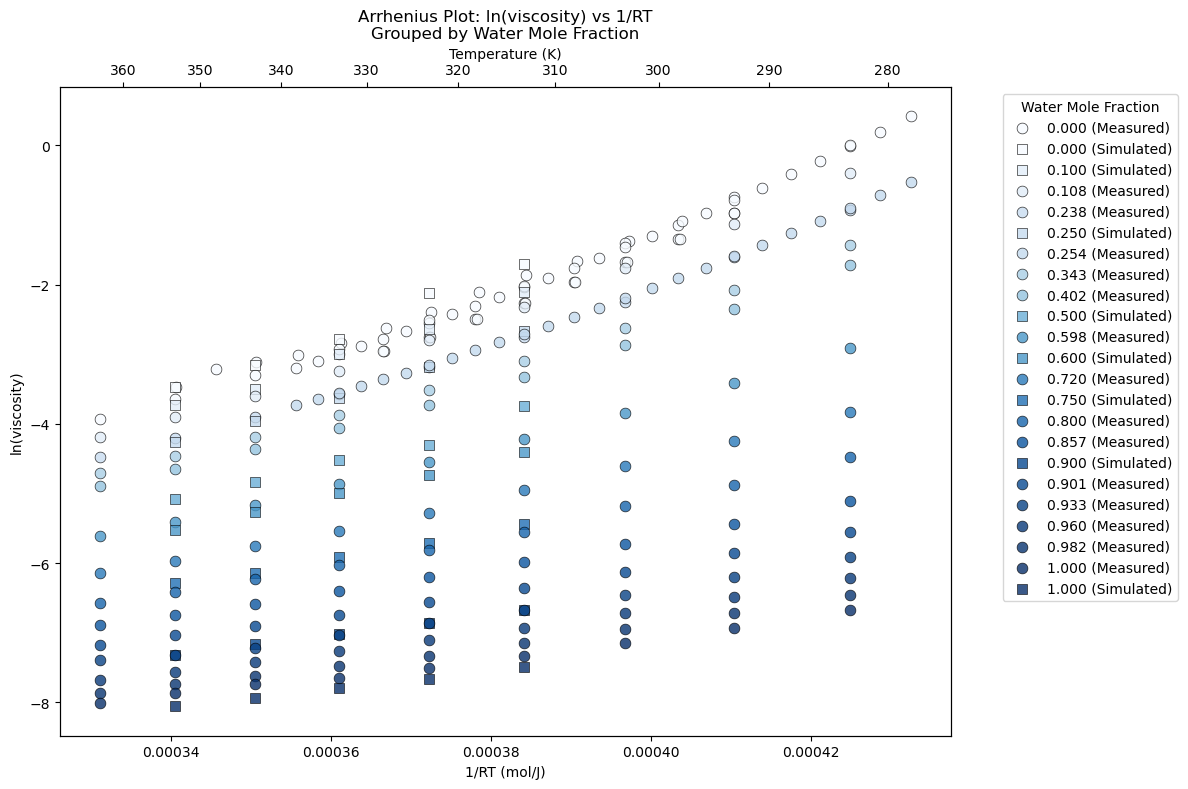

Combined dataset has 244 records

,experiment_id,property_type,property_value,property_uncertainty,mole_fraction_glycerol,mole_fraction_water,mole_fraction_cholinechloride,temperature,method,source_file,source_doi,ln_viscosity,inv_RT
0,0211680d-87a7-44a4-a5a4-e3970990bee4,viscosity,0.113800,0.002276,0.666667,0.0000,0.333333,315.650,measured,Xu_Glycerol_Water.json,10.1016/j.jct.2018.07.031,-2.173313,0.000381
1,12bf784b-1496-4798-9f50-2a1091130712,viscosity,0.062060,0.001241,0.666667,0.0000,0.333333,328.150,measured,Xu_Glycerol_Water.json,10.1016/j.jct.2018.07.031,-2.779654,0.000367
2,1341a5f9-9c59-4680-9a52-7fc54e56e231,viscosity,0.072517,NaN,0.666667,0.0000,0.333333,327.826,measured,Xu_Glycerol_Water.json,10.1016/j.molliq.2015.11.032,-2.623934,0.000367
3,17ef9c6e-eed6-4e5f-9b03-cfeca1e58f0a,viscosity,0.319700,0.006394,0.666667,0.0000,0.333333,298.150,measured,Xu_Glycerol_Water.json,10.1016/j.jct.2018.07.031,-1.140372,0.000403
4,1903429f-f1ad-45b5-a281-d7638e4706b4,viscosity,0.064000,0.001920,0.666667,0.0000,0.333333,323.150,measured,Xu_Glycerol_Water.json,10.1039/c0gc00395f,-2.748872,0.000372
...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,fb4d0eed-5072-4eaf-a2d5-3df73a2840c9,viscosity,0.023845,0.002086,0.600000,0.1000,0.300000,353.150,simulated,spera_et_al_fpe_592_2025_114324.json,10.1016/j.fluid.2024.114324,-3.736164,0.000341
240,fbafb6d0-4b94-4baf-b847-bf20e855a1aa,viscosity,0.014040,0.000475,0.500000,0.2500,0.250000,353.150,simulated,spera_et_al_fpe_592_2025_114324.json,10.1016/j.fluid.2024.114324,-4.265876,0.000341
241,fc083bc7-85e0-4c60-b5f1-f957bc4ecddd,viscosity,0.002406,0.000012,0.133533,0.7997,0.066767,333.150,measured,Xu_Glycerol_Water.json,10.1016/j.fluid.2014.01.028,-6.029665,0.000361
242,ff34d597-5541-4d41-968a-ea4ea7fdb866,viscosity,0.006790,0.000076,0.267000,0.6000,0.133000,333.150,simulated,spera_et_al_fpe_592_2025_114324.json,10.1016/j.fluid.2024.114324,-4.992362,0.000361


In [14]:
# Import required libraries
import matplotlib.pyplot as plt
import numpy as np

# Combine all three dataframes
combined_df = pd.concat([des_pure_df, water_df, des_water_df], ignore_index=True)

# Calculate ln(viscosity) and 1/RT
R = 8.314  # J/(mol·K) - gas constant
combined_df['ln_viscosity'] = np.log(combined_df['property_value'])
combined_df['inv_RT'] = 1 / (R * combined_df['temperature'])

# Fill NaN values in mole_fraction_water with 0 for proper coloring
combined_df['mole_fraction_water'] = combined_df['mole_fraction_water'].fillna(0)

# Create the plot
fig, ax1 = plt.subplots(figsize=(12, 8))

# Get unique water mole fractions and sort them
unique_water_fractions = sorted(combined_df['mole_fraction_water'].unique())

# Create a color map based on actual water fraction values
# Normalize the water fractions to [0, 1] range for color mapping
min_frac = min(unique_water_fractions)
max_frac = max(unique_water_fractions)
norm = plt.Normalize(vmin=min_frac, vmax=max_frac)
cmap = plt.cm.Blues

# Plot data for each unique water fraction
for water_frac in unique_water_fractions:
    # Filter data for this water fraction
    fraction_data = combined_df[combined_df['mole_fraction_water'] == water_frac]
    
    # Get color based on actual water fraction value
    color = cmap(norm(water_frac))
    
    # Separate by method
    measured_data = fraction_data[fraction_data['method'] == 'measured']
    simulated_data = fraction_data[fraction_data['method'] == 'simulated']
    
    # Plot measured data (circles)
    if len(measured_data) > 0:
        ax1.scatter(
            measured_data['inv_RT'], 
            measured_data['ln_viscosity'],
            color=color,
            marker='o',  # circles
            s=60,
            alpha=0.8,
            edgecolors='black',
            linewidth=0.5,
            label=f'{water_frac:.3f} (Measured)'
        )
    
    # Plot simulated data (squares)
    if len(simulated_data) > 0:
        ax1.scatter(
            simulated_data['inv_RT'], 
            simulated_data['ln_viscosity'],
            color=color,
            marker='s',  # squares
            s=60,
            alpha=0.8,
            edgecolors='black',
            linewidth=0.5,
            label=f'{water_frac:.3f} (Simulated)'
        )

ax1.set_xlabel('1/RT (mol/J)')
ax1.set_ylabel('ln(viscosity)')
ax1.set_title('Arrhenius Plot: ln(viscosity) vs 1/RT\nGrouped by Water Mole Fraction')
ax1.grid(False)

# Create second x-axis for temperature
ax2 = ax1.twiny()

# Get the actual data range for 1/RT
inv_rt_min = combined_df['inv_RT'].min()
inv_rt_max = combined_df['inv_RT'].max()

# Add some padding to the range
padding = (inv_rt_max - inv_rt_min) * 0.05
inv_rt_min_padded = inv_rt_min - padding
inv_rt_max_padded = inv_rt_max + padding

# Set the x-axis limits for both axes
ax1.set_xlim(inv_rt_min_padded, inv_rt_max_padded)
ax2.set_xlim(inv_rt_min_padded, inv_rt_max_padded)

# Convert 1/RT back to temperature for the top axis
temp_max = 1 / (R * inv_rt_min_padded)  # Note: inverse relationship
temp_min = 1 / (R * inv_rt_max_padded)

# Create temperature tick locations based on the actual data range
# Use reasonable temperature intervals
temp_range = temp_max - temp_min
if temp_range > 100:
    temp_interval = 20
elif temp_range > 50:
    temp_interval = 10
else:
    temp_interval = 5

# Generate temperature ticks
temp_start = int(temp_min / temp_interval) * temp_interval
temp_end = int(temp_max / temp_interval + 1) * temp_interval
temp_ticks = np.arange(temp_start, temp_end + temp_interval, temp_interval)

# Filter to only include temperatures within our range
temp_ticks = temp_ticks[(temp_ticks >= temp_min) & (temp_ticks <= temp_max)]

# Convert temperature ticks to 1/RT values for positioning
inv_rt_ticks = 1 / (R * temp_ticks)

# Set the ticks and labels
ax2.set_xticks(inv_rt_ticks)
ax2.set_xticklabels([f'{int(t)}' for t in temp_ticks])
ax2.set_xlabel('Temperature (K)')

# Add legend
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Water Mole Fraction')
plt.tight_layout()
plt.show()

# Display the combined dataframe
print(f"Combined dataset has {len(combined_df)} records")
combined_df

Available columns:
[
    'experiment_id',
    'property_type',
    'property_value',
    'property_uncertainty',
    'mole_fraction_glycerol',
    'mole_fraction_water',
    'mole_fraction_cholinechloride',
    'temperature',
    'method',
    'source_file',
    'source_doi',
    'ln_viscosity',
    'inv_RT'
]

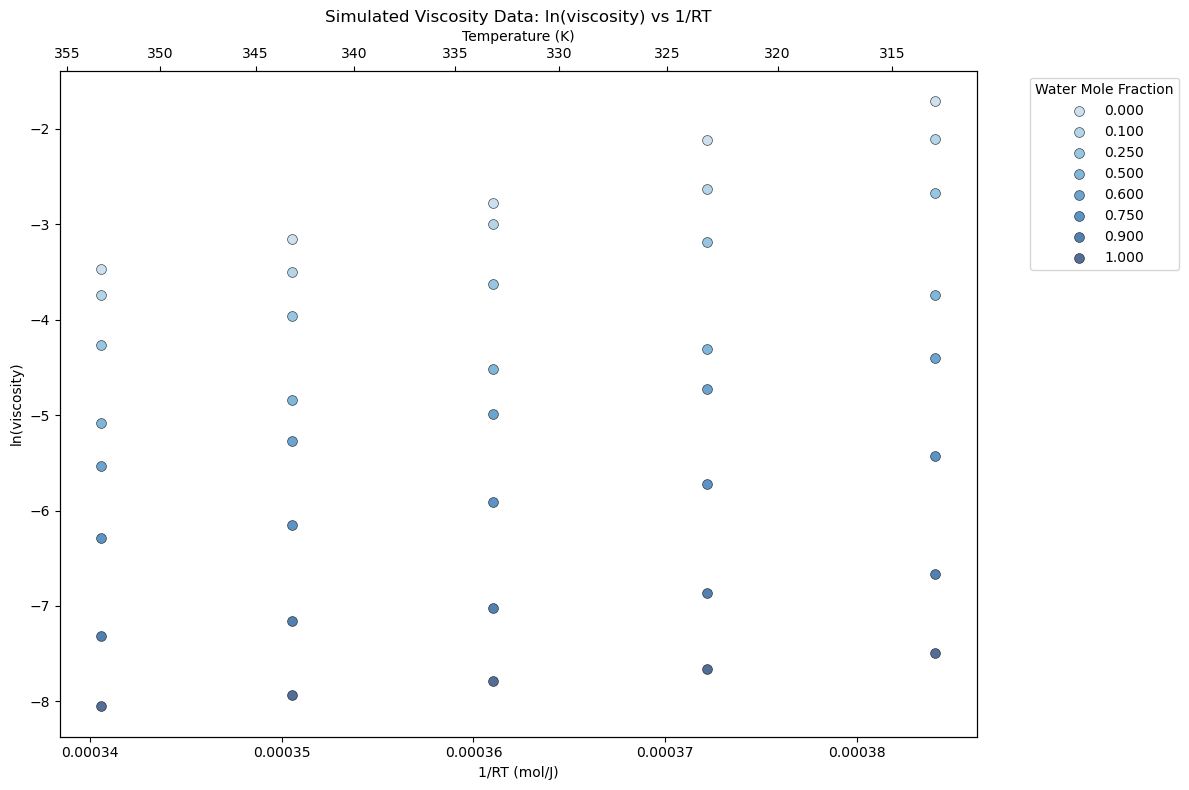

Simulated dataset has 40 records

In [21]:
# Filter for simulated data only
simulated_df = combined_df[combined_df['method'] == 'simulated'].copy()

# Check what columns are available
print("Available columns:", simulated_df.columns.tolist())

# Plot simulated data
plt.figure(figsize=(12, 8))

# Create the main plot
ax1 = plt.gca()

# Check if we have a water mole fraction column (it might be named differently)
water_fraction_col = None
for col in simulated_df.columns:
    if 'water' in col.lower() and ('fraction' in col.lower() or 'mole' in col.lower()):
        water_fraction_col = col
        break

# Plot simulated data points
if water_fraction_col is not None:
    # Get unique water fractions and sort them
    unique_fractions = sorted(simulated_df[water_fraction_col].unique())
    
    # Create a color palette
    colors = plt.cm.Blues(np.linspace(0.3, 1.0, len(unique_fractions)))
    
    # Plot each water fraction separately for legend
    for i, fraction in enumerate(unique_fractions):
        mask = simulated_df[water_fraction_col] == fraction
        ax1.scatter(simulated_df[mask]['inv_RT'], simulated_df[mask]['ln_viscosity'], 
                   alpha=0.7, s=50, color=colors[i],
                   edgecolors='black', linewidths=0.5,
                   label=f'{fraction:.3f}')
    
    # Add legend
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Water Mole Fraction')
else:
    # Plot without color coding if water fraction column not found
    scatter = ax1.scatter(simulated_df['inv_RT'], simulated_df['ln_viscosity'], 
                         alpha=0.7, s=50, label='Simulated', color='blue',
                         edgecolors='black', linewidths=0.5)
    ax1.legend()

# Set labels and title
ax1.set_xlabel('1/RT (mol/J)')
ax1.set_ylabel('ln(viscosity)')
ax1.set_title('Simulated Viscosity Data: ln(viscosity) vs 1/RT')

# Create secondary x-axis for temperature
ax2 = ax1.twiny()

# Calculate axis limits with padding
R = 8.314  # Gas constant
inv_rt_min = simulated_df['inv_RT'].min()
inv_rt_max = simulated_df['inv_RT'].max()
padding = (inv_rt_max - inv_rt_min) * 0.05
inv_rt_min_padded = inv_rt_min - padding
inv_rt_max_padded = inv_rt_max + padding

# Set the x-axis limits for both axes
ax1.set_xlim(inv_rt_min_padded, inv_rt_max_padded)
ax2.set_xlim(inv_rt_min_padded, inv_rt_max_padded)

# Convert 1/RT back to temperature for the top axis
temp_max = 1 / (R * inv_rt_min_padded)  # Note: inverse relationship
temp_min = 1 / (R * inv_rt_max_padded)

# Create temperature tick locations based on the actual data range
temp_range = temp_max - temp_min
if temp_range > 100:
    temp_interval = 20
elif temp_range > 50:
    temp_interval = 10
else:
    temp_interval = 5

# Generate temperature ticks
temp_start = int(temp_min / temp_interval) * temp_interval
temp_end = int(temp_max / temp_interval + 1) * temp_interval
temp_ticks = np.arange(temp_start, temp_end + temp_interval, temp_interval)

# Filter to only include temperatures within our range
temp_ticks = temp_ticks[(temp_ticks >= temp_min) & (temp_ticks <= temp_max)]

# Convert temperature ticks to 1/RT values for positioning
inv_rt_ticks = 1 / (R * temp_ticks)

# Set the ticks and labels
ax2.set_xticks(inv_rt_ticks)
ax2.set_xticklabels([f'{int(t)}' for t in temp_ticks])
ax2.set_xlabel('Temperature (K)')

plt.tight_layout()
plt.show()

print(f"Simulated dataset has {len(simulated_df)} records")

In [48]:
combined_df = pd.concat([des_pure_df, water_df, des_water_df], ignore_index=True).fillna(0)

# Calculate derived columns needed for activation energy analysis
R = 8.314  # Gas constant J/(mol·K)
combined_df['ln_viscosity'] = np.log(combined_df['property_value'])
combined_df['inv_RT'] = 1 / (R * combined_df['temperature'])

# Calculate activation energy for each composition, DOI, and method separately
activation_energies = []

# Group by composition (mole fractions), DOI, and method
grouped = combined_df.groupby(['mole_fraction_glycerol', 'mole_fraction_water', 'mole_fraction_cholinechloride', 'source_doi', 'method'])

for (glycerol_frac, water_frac, cc_frac, doi, method), group in grouped:
    if len(group) >= 2:  # Need at least 2 points for linear regression
        # Perform linear regression: ln(viscosity) = A + B*(1/RT)
        slope, intercept, r_value, p_value, std_err = stats.linregress(group['inv_RT'], group['ln_viscosity'])
        
        activation_energy = slope
        ln_pre_exponential = intercept
        
        activation_energies.append({
            'mole_fraction_glycerol': glycerol_frac,
            'mole_fraction_water': water_frac,
            'mole_fraction_cholinechloride': cc_frac,
            'source_doi': doi,
            'method': method,
            'activation_energy_J_mol': activation_energy,
            'ln_pre_exponential': ln_pre_exponential,
            'r_squared': r_value**2,
            'p_value': p_value,
            'n_points': len(group),
            'temp_range_K': f"{group['temperature'].min():.1f}-{group['temperature'].max():.1f}"
        })

# Convert to DataFrame for easier viewing
activation_df = pd.DataFrame(activation_energies)
activation_df = activation_df.sort_values('activation_energy_J_mol')

print(f"Calculated activation energies for {len(activation_df)} composition-DOI-method combinations:")
display(activation_df)

/tmp/ipykernel_8071/1818451945.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df = pd.concat([des_pure_df, water_df, des_water_df], ignore_index=True).fillna(0)


Calculated activation energies for 27 composition-DOI-method combinations:

,mole_fraction_glycerol,mole_fraction_water,mole_fraction_cholinechloride,source_doi,method,activation_energy_J_mol,ln_pre_exponential,r_squared,p_value,n_points,temp_range_K
1,0.000000,1.000000,0.000000,10.1016/j.fluid.2024.114324,simulated,12864.252347,-12.438768,0.999575,3.721386e-06,5,313.1-353.1
0,0.000000,1.000000,0.000000,10.1016/j.fluid.2014.01.028,measured,13957.939791,-12.655573,0.992359,1.138483e-08,9,283.1-363.1
6,0.067000,0.900000,0.033000,10.1016/j.fluid.2024.114324,simulated,14635.867659,-12.297098,0.998630,2.153542e-05,5,313.1-353.1
2,0.012067,0.981900,0.006033,10.1016/j.fluid.2014.01.028,measured,14912.521507,-12.841238,0.995354,1.992543e-09,9,283.1-363.1
3,0.026533,0.960200,0.013267,10.1016/j.fluid.2014.01.028,measured,15546.665223,-12.863887,0.996224,9.646646e-10,9,283.1-363.1
4,0.044333,0.933500,0.022167,10.1016/j.fluid.2014.01.028,measured,16013.872479,-12.784446,0.991342,1.763585e-08,9,283.1-363.1
5,0.066200,0.900700,0.033100,10.1016/j.fluid.2014.01.028,measured,17207.759499,-12.922000,0.994749,3.059928e-09,9,283.1-363.1
7,0.095067,0.857400,0.047533,10.1016/j.fluid.2014.01.028,measured,18893.527986,-13.195562,0.995529,1.742327e-09,9,283.1-363.1
9,0.167000,0.750000,0.083000,10.1016/j.fluid.2024.114324,simulated,19799.898023,-13.060908,0.994204,1.876227e-04,5,313.1-353.1
8,0.133533,0.799700,0.066767,10.1016/j.fluid.2014.01.028,measured,22366.546410,-14.060410,0.993082,8.035725e-09,9,283.1-363.1


<>:30: SyntaxWarning: invalid escape sequence '\c'
<>:31: SyntaxWarning: invalid escape sequence '\c'
<>:30: SyntaxWarning: invalid escape sequence '\c'
<>:31: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_8071/2847344150.py:30: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel('$\chi_W$')
/tmp/ipykernel_8071/2847344150.py:31: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('Activation Energy $E_a$ / $kJ \cdot mol^{-1}$')


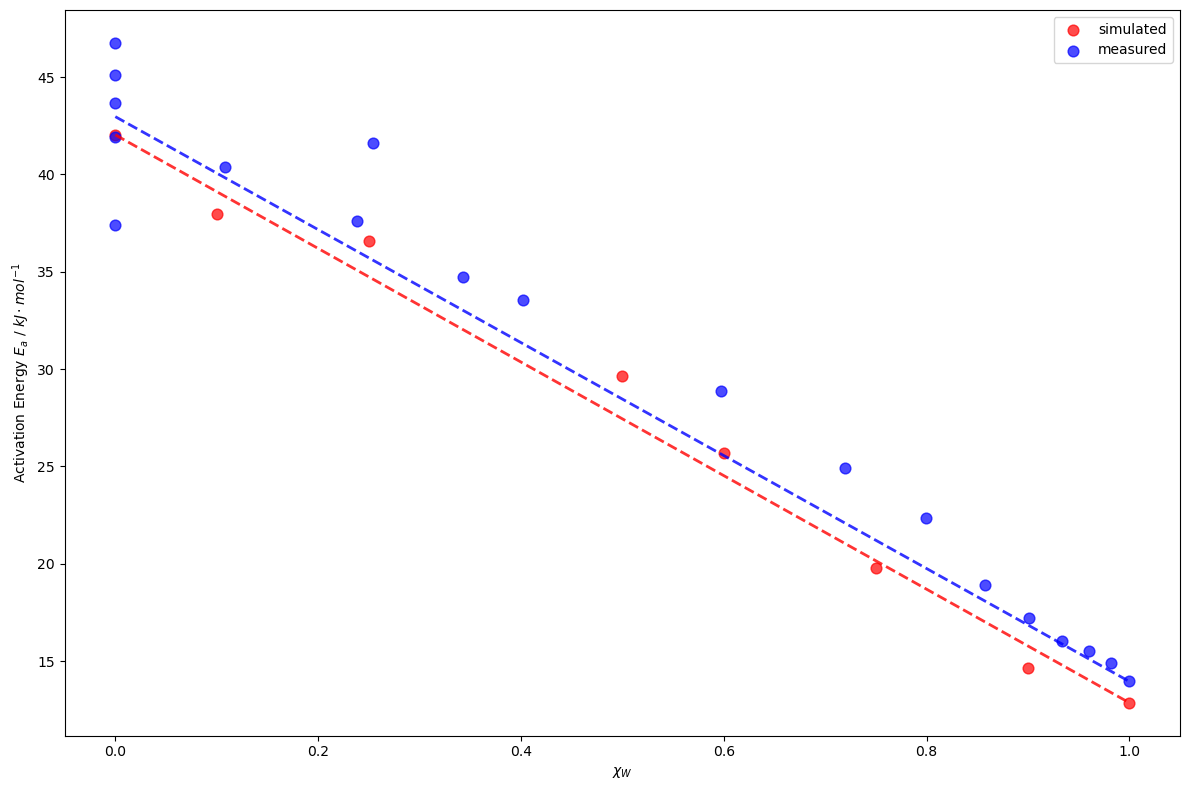

In [80]:
# Plot activation energy vs water content, colored by method
plt.figure(figsize=(12, 8))

# Create scatter plot with red and blue colors
colors = ['red', 'blue']
for i, method in enumerate(activation_df['method'].unique()):
    method_data = activation_df[activation_df['method'] == method]
    plt.scatter(method_data['mole_fraction_water'], 
               method_data['activation_energy_J_mol'] / 1000,
               label=method, 
               alpha=0.7,
               s=60,
               color=colors[i % len(colors)])
    
    # Calculate mean activation energy for 0 and 1 mole fraction water
    water_0_data = method_data[method_data['mole_fraction_water'] == 0]
    water_1_data = method_data[method_data['mole_fraction_water'] == 1]
    
    if len(water_0_data) > 0 and len(water_1_data) > 0:
        mean_ea_0 = water_0_data['activation_energy_J_mol'].mean() / 1000
        mean_ea_1 = water_1_data['activation_energy_J_mol'].mean() / 1000
        
        # Connect the points with a line
        plt.plot([0, 1], [mean_ea_0, mean_ea_1], 
                color=colors[i % len(colors)], 
                linestyle='--', 
                alpha=0.8,
                linewidth=2)

plt.xlabel('$\chi_W$')
plt.ylabel('Activation Energy $E_a$ / $kJ \cdot mol^{-1}$')
plt.legend()
plt.tight_layout()
plt.show()

<>:77: SyntaxWarning: invalid escape sequence '\c'
<>:80: SyntaxWarning: invalid escape sequence '\c'
<>:81: SyntaxWarning: invalid escape sequence '\D'
<>:77: SyntaxWarning: invalid escape sequence '\c'
<>:80: SyntaxWarning: invalid escape sequence '\c'
<>:81: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_8071/1378847495.py:77: SyntaxWarning: invalid escape sequence '\c'
  legend_handles.append(Patch(facecolor='black', edgecolor='k', label='Mean of $E_a$ at $\chi_W = 0$'))
/tmp/ipykernel_8071/1378847495.py:80: SyntaxWarning: invalid escape sequence '\c'
  ax.set_xlabel('$\chi_W$')
/tmp/ipykernel_8071/1378847495.py:81: SyntaxWarning: invalid escape sequence '\D'
  ax.set_ylabel('$\Delta E_a^{excess}$ / $kJ \cdot mol^{-1}$')


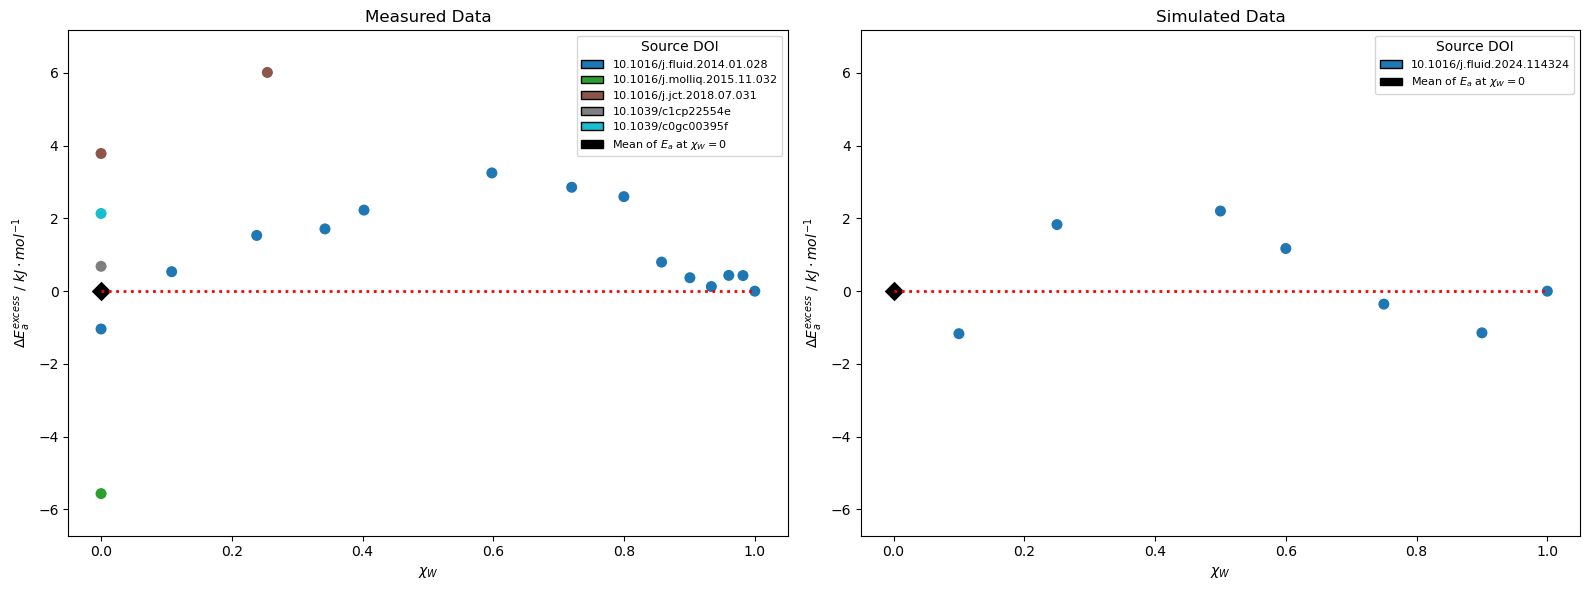

In [77]:
# Plot excess activation energy vs water content, separated by method
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Process each method separately
methods = activation_df['method'].unique()

# Store all residues to determine common y-axis limits
all_residues = []

for idx, method in enumerate(methods):
    ax = ax1 if method == 'measured' else ax2
    method_data = activation_df[activation_df['method'] == method]
    
    # Calculate mean activation energy for zero and one water content (in J/mol)
    mean_0_water = method_data[method_data['mole_fraction_water'] == 0.0]['activation_energy_J_mol'].mean()
    mean_1_water = method_data[method_data['mole_fraction_water'] == 1.0]['activation_energy_J_mol'].mean()
    
    # Calculate the linear trend line values for each data point
    water_fractions = method_data['mole_fraction_water']
    trend_line_values = mean_0_water + (mean_1_water - mean_0_water) * water_fractions
    
    # Calculate residues (excess activation energy) in kJ/mol
    residues = (method_data['activation_energy_J_mol'] - trend_line_values) / 1000
    all_residues.extend(residues)
    
    # Separate zero water content data
    zero_water_mask = method_data['mole_fraction_water'] == 0.0
    other_mask = method_data['mole_fraction_water'] != 0.0
    
    # Create color map for DOIs
    unique_dois = method_data['source_doi'].unique()
    colors_map = plt.cm.tab10(np.linspace(0, 1, len(unique_dois)))
    doi_colors = {doi: colors_map[i] for i, doi in enumerate(unique_dois)}
    method_data_colors = method_data['source_doi'].map(doi_colors)
    
    # Plot zero water content points
    if zero_water_mask.any():
        ax.scatter(
            method_data[zero_water_mask]['mole_fraction_water'],
            residues[zero_water_mask],
            c=[doi_colors[doi] for doi in method_data[zero_water_mask]['source_doi']],
            s=80,
            edgecolor='w'
        )
    
    # Plot the mean point for zero water content
    zero_water_residue = (mean_0_water - mean_0_water) / 1000  # This will be 0
    ax.scatter(
        0.0,
        zero_water_residue,
        c='black',
        s=120,
        edgecolor='w',
        marker='D',
        label='Mean (0% water)'
    )
    
    # Plot other data points colored by DOI
    if other_mask.any():
        ax.scatter(
            method_data[other_mask]['mole_fraction_water'],
            residues[other_mask],
            c=[doi_colors[doi] for doi in method_data[other_mask]['source_doi']],
            s=80,
            edgecolor='w'
        )
    
    # Add dotted red line connecting mean at mole fraction 0 to mole fraction 1
    one_water_residue = (mean_1_water - (mean_0_water + (mean_1_water - mean_0_water) * 1.0)) / 1000
    ax.plot([0.0, 1.0], [zero_water_residue, one_water_residue], 'r:', linewidth=2, label='Mean trend')
    
    # Create legend for DOIs
    from matplotlib.patches import Patch
    legend_handles = []
    for doi in unique_dois:
        legend_handles.append(Patch(facecolor=doi_colors[doi], edgecolor='k', label=f"{doi}"))
    legend_handles.append(Patch(facecolor='black', edgecolor='k', label='Mean of $E_a$ at $\chi_W = 0$'))
    
    ax.legend(handles=legend_handles, title="Source DOI", fontsize=8)
    ax.set_xlabel('$\chi_W$')
    ax.set_ylabel('$\Delta E_a^{excess}$ / $kJ \cdot mol^{-1}$')
    ax.set_title(f'{method.capitalize()} Data')

# Set common y-axis limits for both subplots
y_min = min(all_residues)
y_max = max(all_residues)
y_margin = (y_max - y_min) * 0.1
ax1.set_ylim(y_min - y_margin, y_max + y_margin)
ax2.set_ylim(y_min - y_margin, y_max + y_margin)

plt.tight_layout()
plt.show()

<>:16: SyntaxWarning: invalid escape sequence '\c'
<>:16: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_8071/2694142281.py:16: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('Activation Energy $E_a$ / $J \cdot mol^{-1}$')


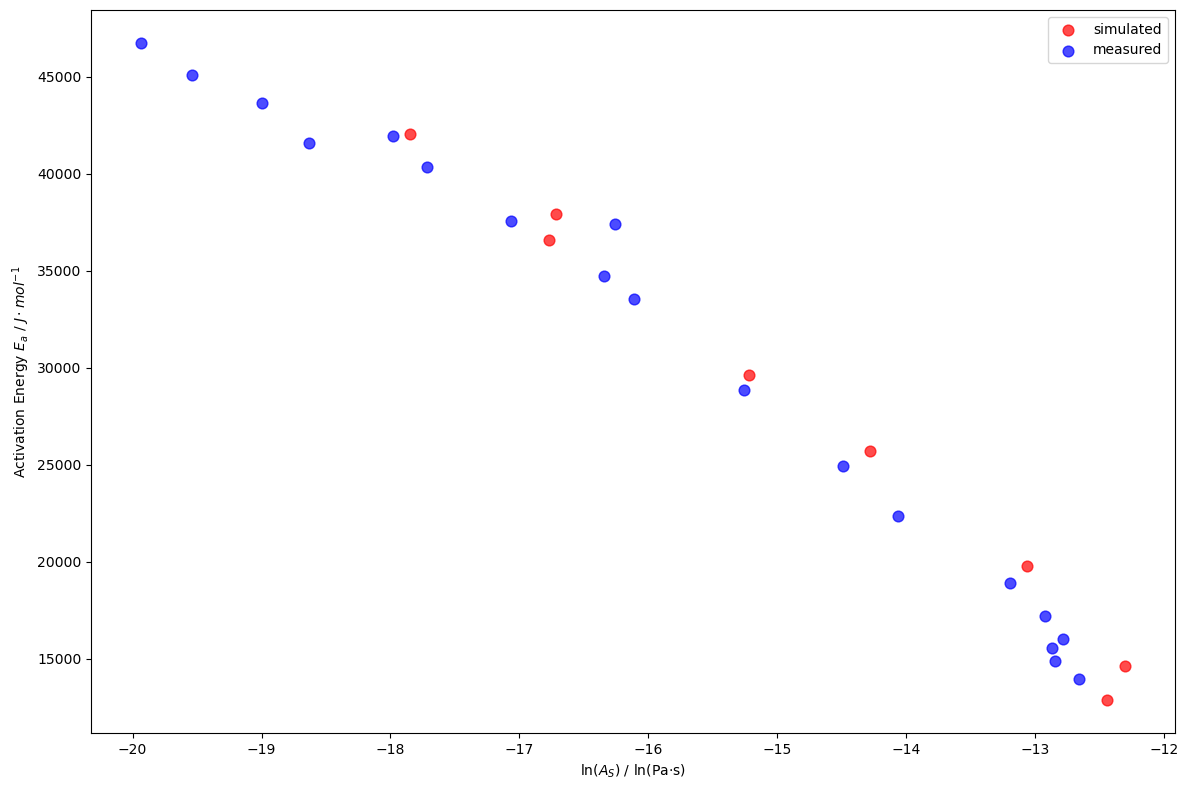

In [50]:
# Plot activation energy vs ln(A) colored by method
plt.figure(figsize=(12, 8))

# Create scatter plot with red and blue colors
colors = ['red', 'blue']
for i, method in enumerate(activation_df['method'].unique()):
    method_data = activation_df[activation_df['method'] == method]
    plt.scatter(method_data['ln_pre_exponential'], 
               method_data['activation_energy_J_mol'],
               label=method, 
               alpha=0.7,
               s=60,
               color=colors[i % len(colors)])

plt.xlabel('ln($A_S$) / ln(Pa·s)')
plt.ylabel('Activation Energy $E_a$ / $J \cdot mol^{-1}$')
plt.legend()
plt.tight_layout()
plt.show()

<>:30: SyntaxWarning: invalid escape sequence '\c'
<>:30: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_8071/345008102.py:30: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel('$\chi_W$ Mole Fraction Water')


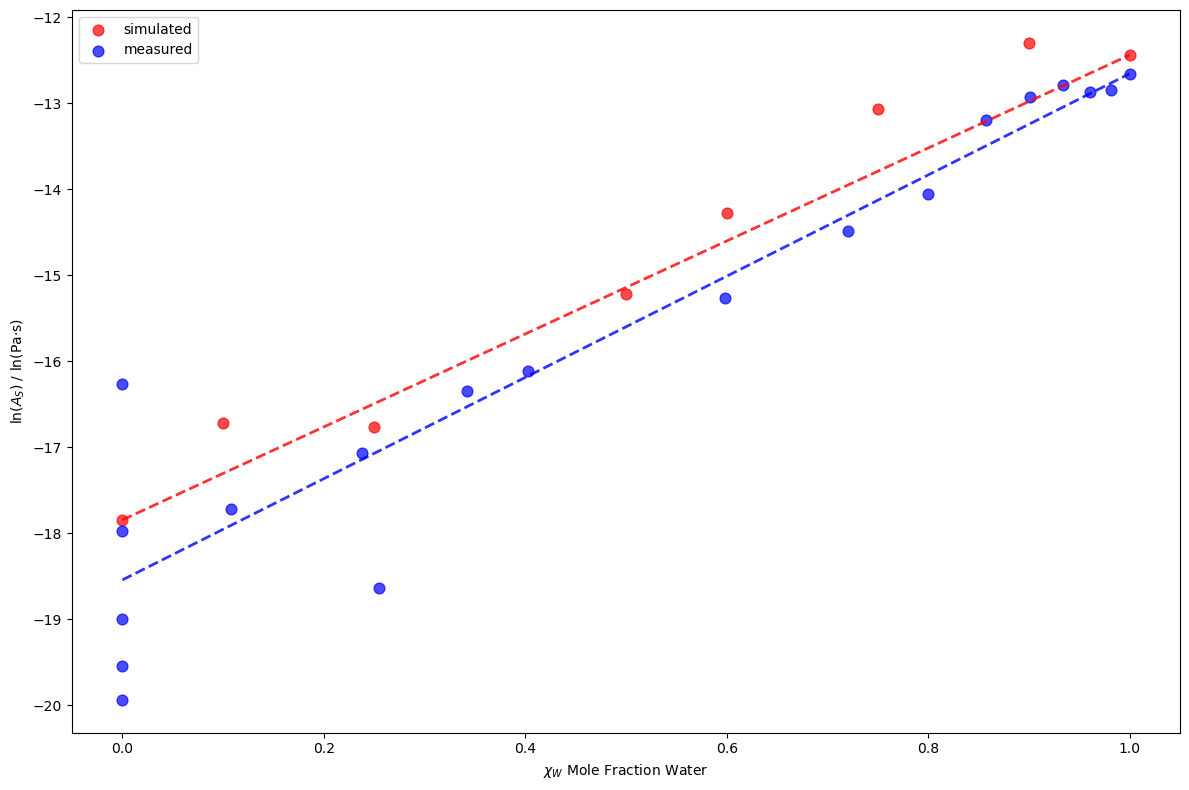

In [52]:
# Plot ln(A) vs mole fraction water colored by method
plt.figure(figsize=(12, 8))

# Create scatter plot with red and blue colors
colors = ['red', 'blue']
for i, method in enumerate(activation_df['method'].unique()):
    method_data = activation_df[activation_df['method'] == method]
    plt.scatter(method_data['mole_fraction_water'], 
               method_data['ln_pre_exponential'],
               label=method, 
               alpha=0.7,
               s=60,
               color=colors[i % len(colors)])
    
    # Calculate mean ln(A) for 0 and 1 mole fraction water
    water_0_data = method_data[method_data['mole_fraction_water'] == 0]
    water_1_data = method_data[method_data['mole_fraction_water'] == 1]
    
    if len(water_0_data) > 0 and len(water_1_data) > 0:
        mean_lnA_0 = water_0_data['ln_pre_exponential'].mean()
        mean_lnA_1 = water_1_data['ln_pre_exponential'].mean()
        
        # Connect the points with a line
        plt.plot([0, 1], [mean_lnA_0, mean_lnA_1], 
                color=colors[i % len(colors)], 
                linestyle='--', 
                alpha=0.8,
                linewidth=2)

plt.xlabel('$\chi_W$ Mole Fraction Water')
plt.ylabel('ln($A_S$) / ln(Pa·s)')
plt.legend()
plt.tight_layout()
plt.show()

In [60]:
# Use the combined_df from earlier cells and filter for high temperature group
# First, recreate the split logic if needed

# Create a composition identifier from mole fractions for grouping
def get_composition_key(row):
    """Convert mole fractions to a hashable tuple for grouping."""
    # Collect all mole fraction columns
    mf_cols = ['mole_fraction_glycerol', 'mole_fraction_water', 'mole_fraction_cholinechloride']
    mf_values = []
    for col in mf_cols:
        if col in row.index and pd.notna(row[col]):
            mf_values.append(round(float(row[col]), 3))
    return tuple(mf_values) if mf_values else None

combined_df['composition_key'] = combined_df.apply(get_composition_key, axis=1)

# Get unique combinations of DOI and composition
doi_composition_combinations = combined_df[
    combined_df['composition_key'].notna() &
    combined_df['source_doi'].notna() &
    (~combined_df["inv_RT"].isna()) &
    (~combined_df["ln_viscosity"].isna())
][['source_doi', 'composition_key']].drop_duplicates()

# List to store all split data
split_data = []

# Process each valid DOI-composition combination - split into temperature groups (High T and Low T)
for _, row in doi_composition_combinations.iterrows():
    doi = row['source_doi']
    comp_key = row['composition_key']
    
    subset = combined_df[
        (combined_df["source_doi"] == doi) &
        (combined_df["composition_key"] == comp_key) &
        (~combined_df["inv_RT"].isna()) &
        (~combined_df["ln_viscosity"].isna())
    ]
    
    if len(subset) < 2:
        continue  # Not enough points to split
    
    # Check if this is simulated data
    method = subset['method'].iloc[0]
    
    if method == 'simulated':
        # Keep simulated data complete without splitting
        subset_copy = subset.copy()
        subset_copy['temperature_group'] = 'High T'
        split_data.append(subset_copy)
    else:
        # Split measured data into two halves based on temperature
        # Sort by temperature (inverse of inv_RT for proper ordering)
        subset_sorted = subset.sort_values('inv_RT')
        
        # Split into two halves based on temperature
        n_points = len(subset_sorted)
        mid_point = n_points // 2
        
        # Lower half (higher temperatures - lower inv_RT values)
        low_temp_group = subset_sorted.iloc[:mid_point].copy()
        low_temp_group['temperature_group'] = 'High T'
        
        # Upper half (lower temperatures - higher inv_RT values)  
        high_temp_group = subset_sorted.iloc[mid_point:].copy()
        high_temp_group['temperature_group'] = 'Low T'
        
        # Add to split_data list
        split_data.append(low_temp_group)
        split_data.append(high_temp_group)

# Combine all split data into a single DataFrame
split_points_df = pd.concat(split_data, ignore_index=True)

# Filter for High T temperature group only
high_temp_df = split_points_df[split_points_df['temperature_group'] == 'High T'].copy()

print(f"High temperature data shape: {high_temp_df.shape}")
print(f"Number of unique DOI-composition combinations: {high_temp_df[['source_doi', 'composition_key']].drop_duplicates().shape[0]}")
display(high_temp_df.head(10))

High temperature data shape: (133, 15)

Number of unique DOI-composition combinations: 27

,experiment_id,property_type,property_value,property_uncertainty,mole_fraction_glycerol,mole_fraction_water,mole_fraction_cholinechloride,temperature,method,source_file,source_doi,ln_viscosity,inv_RT,composition_key,temperature_group
0,e2f84b2e-9823-474e-a97d-0c4ee5e55b63,viscosity,0.04094,0.000819,0.666667,0.0,0.333333,338.15,measured,Xu_Glycerol_Water.json,10.1016/j.jct.2018.07.031,-3.195648,0.000356,"(0.667, 0.0, 0.333)",High T
1,d66c103f-3bd6-457c-8308-7ba54b39962d,viscosity,0.04519,0.000904,0.666667,0.0,0.333333,335.65,measured,Xu_Glycerol_Water.json,10.1016/j.jct.2018.07.031,-3.096879,0.000358,"(0.667, 0.0, 0.333)",High T
2,2fd83554-a868-4c0d-b1a3-42c297bf9e22,viscosity,0.05005,0.001001,0.666667,0.0,0.333333,333.15,measured,Xu_Glycerol_Water.json,10.1016/j.jct.2018.07.031,-2.994733,0.000361,"(0.667, 0.0, 0.333)",High T
3,1f71b285-9cc2-4d35-877b-530c6a1794fb,viscosity,0.05563,0.001113,0.666667,0.0,0.333333,330.65,measured,Xu_Glycerol_Water.json,10.1016/j.jct.2018.07.031,-2.889033,0.000364,"(0.667, 0.0, 0.333)",High T
4,12bf784b-1496-4798-9f50-2a1091130712,viscosity,0.06206,0.001241,0.666667,0.0,0.333333,328.15,measured,Xu_Glycerol_Water.json,10.1016/j.jct.2018.07.031,-2.779654,0.000367,"(0.667, 0.0, 0.333)",High T
5,aa9d3ba7-3c6a-48c3-817a-b866cfa0753c,viscosity,0.06946,0.001389,0.666667,0.0,0.333333,325.65,measured,Xu_Glycerol_Water.json,10.1016/j.jct.2018.07.031,-2.667004,0.000369,"(0.667, 0.0, 0.333)",High T
6,1dccada7-2f23-4c8f-8cc4-2b52334e855f,viscosity,0.07839,0.001568,0.666667,0.0,0.333333,323.15,measured,Xu_Glycerol_Water.json,10.1016/j.jct.2018.07.031,-2.546059,0.000372,"(0.667, 0.0, 0.333)",High T
7,5467e7b9-c042-471b-ad21-9f40e4159d75,viscosity,0.08843,0.001769,0.666667,0.0,0.333333,320.65,measured,Xu_Glycerol_Water.json,10.1016/j.jct.2018.07.031,-2.425544,0.000375,"(0.667, 0.0, 0.333)",High T
8,d30cbcce-e74b-4eb0-973e-9fd7aec3b712,viscosity,0.10000,0.002000,0.666667,0.0,0.333333,318.15,measured,Xu_Glycerol_Water.json,10.1016/j.jct.2018.07.031,-2.302585,0.000378,"(0.667, 0.0, 0.333)",High T
9,0211680d-87a7-44a4-a5a4-e3970990bee4,viscosity,0.11380,0.002276,0.666667,0.0,0.333333,315.65,measured,Xu_Glycerol_Water.json,10.1016/j.jct.2018.07.031,-2.173313,0.000381,"(0.667, 0.0, 0.333)",High T


In [62]:
# Check temperature range for simulated data in high_temp_df
simulated_high_temp = high_temp_df[high_temp_df['method'] == 'simulated']
if len(simulated_high_temp) > 0:
    min_temp = simulated_high_temp['temperature'].min()
    max_temp = simulated_high_temp['temperature'].max()
    print(f"Simulated data temperature range: {min_temp:.2f} K to {max_temp:.2f} K")
    print(f"Number of simulated points: {len(simulated_high_temp)}")
else:
    print("No simulated data found in high_temp_df")


Simulated data temperature range: 313.15 K to 353.15 K

Number of simulated points: 40

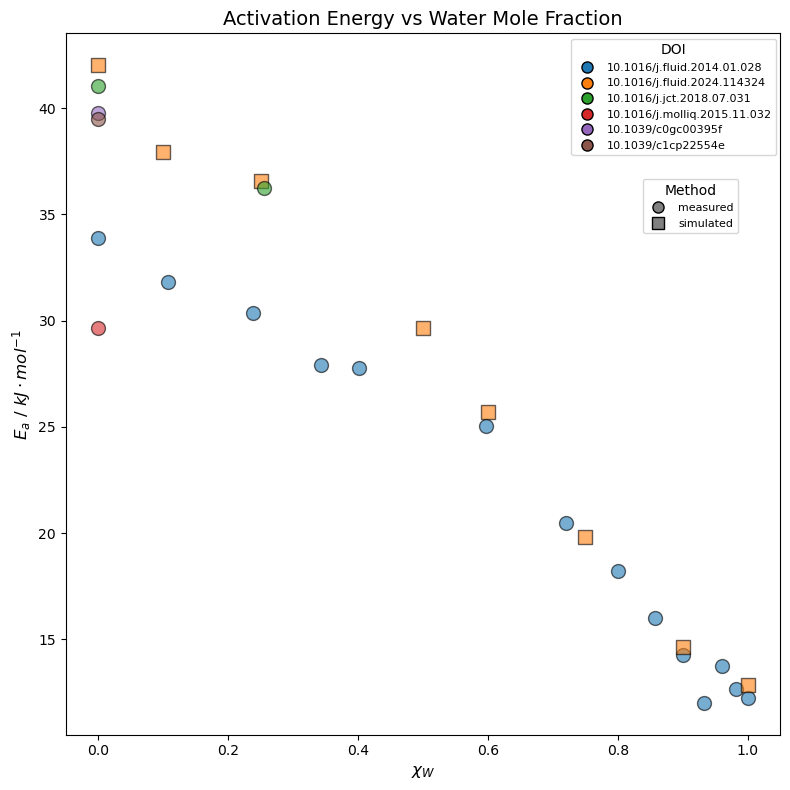

Calculated activation energies for 27 high-temperature composition-DOI combinations

,source_doi,composition_key,mole_fraction_water,method,activation_energy_J_mol,ln_pre_exponential,r_squared,p_value,n_points
13,10.1016/j.fluid.2014.01.028,"(0.667, 0.0, 0.333)",0.000000,measured,33879.814347,-15.165900,0.999022,4.889805e-04,4
25,10.1039/c0gc00395f,"(0.667, 0.0, 0.333)",0.000000,measured,39776.179434,-17.542429,0.999304,3.479948e-04,4
21,10.1016/j.fluid.2024.114324,"(0.667, 0.0, 0.333)",0.000000,simulated,42029.324327,-17.845349,0.989444,4.617843e-04,5
26,10.1039/c1cp22554e,"(0.667, 0.0, 0.333)",0.000000,measured,39512.914778,-17.451681,0.998239,2.671985e-02,3
24,10.1016/j.molliq.2015.11.032,"(0.667, 0.0, 0.333)",0.000000,measured,29642.977920,-13.525274,0.975107,2.343343e-04,6
23,10.1016/j.jct.2018.07.031,"(0.667, 0.0, 0.333)",0.000000,measured,41070.883460,-17.823342,0.999330,3.322528e-17,12
20,10.1016/j.fluid.2024.114324,"(0.6, 0.1, 0.3)",0.100000,simulated,37944.135877,-16.718555,0.992833,2.580915e-04,5
12,10.1016/j.fluid.2014.01.028,"(0.595, 0.108, 0.297)",0.108000,measured,31815.470321,-14.733084,0.998983,5.087028e-04,4
11,10.1016/j.fluid.2014.01.028,"(0.508, 0.238, 0.254)",0.238100,measured,30343.060020,-14.530880,0.999396,3.019892e-04,4
19,10.1016/j.fluid.2024.114324,"(0.5, 0.25, 0.25)",0.250000,simulated,36568.253101,-16.767117,0.994475,1.745761e-04,5


In [74]:
# Calculate activation energies for high temperature data using scipy.stats.linregress
from scipy import stats

high_temp_results = []

for (doi, comp_key), group in high_temp_df.groupby(['source_doi', 'composition_key']):
    if len(group) > 2:
        # Perform linear regression: ln(viscosity) = A + B*(1/RT)
        slope, intercept, r_value, p_value, std_err = stats.linregress(group['inv_RT'], group['ln_viscosity'])
        
        activation_energy = slope
        ln_pre_exponential = intercept
        
        # Get water mole fraction and method
        water_frac = group['mole_fraction_water'].iloc[0]
        method = group['method'].iloc[0]
        
        high_temp_results.append({
            'source_doi': doi,
            'composition_key': comp_key,
            'mole_fraction_water': water_frac,
            'method': method,
            'activation_energy_J_mol': activation_energy,
            'ln_pre_exponential': ln_pre_exponential,
            'r_squared': r_value**2,
            'p_value': p_value,
            'n_points': len(group)
        })

high_temp_ea_df = pd.DataFrame(high_temp_results)

# Plot activation energy vs water mole fraction with color by DOI and shape by method
plt.figure(figsize=(8, 8))

# Get unique DOIs and methods for color and marker mapping
unique_dois = high_temp_ea_df['source_doi'].unique()
unique_methods = high_temp_ea_df['method'].unique()

# Create color map for DOIs
colors = plt.cm.tab10(range(len(unique_dois)))
doi_color_map = dict(zip(unique_dois, colors))

# Create marker map for methods
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
method_marker_map = dict(zip(unique_methods, markers[:len(unique_methods)]))

# Plot each point with appropriate color and marker
for _, row in high_temp_ea_df.iterrows():
    plt.scatter(row['mole_fraction_water'], row['activation_energy_J_mol'] / 1000,
                c=[doi_color_map[row['source_doi']]], 
                marker=method_marker_map[row['method']],
                s=100, alpha=0.6, edgecolors='black')

# Create legends
from matplotlib.lines import Line2D
# DOI legend (colors)
doi_legend_elements = [Line2D([0], [0], marker='o', color='w', 
                              markerfacecolor=doi_color_map[doi], markersize=8, 
                              label=doi, markeredgecolor='black')
                       for doi in unique_dois]
# Method legend (shapes)
method_legend_elements = [Line2D([0], [0], marker=method_marker_map[method], color='w',
                                 markerfacecolor='gray', markersize=8,
                                 label=method, markeredgecolor='black')
                          for method in unique_methods]

# Add both legends
first_legend = plt.legend(handles=doi_legend_elements, title='DOI', 
                         loc='upper left', bbox_to_anchor=(0.7, 1), fontsize=8)
plt.gca().add_artist(first_legend)
plt.legend(handles=method_legend_elements, title='Method',
          loc='upper left', bbox_to_anchor=(0.8, 0.8), fontsize=8)

plt.xlabel(r'$\chi_W$', fontsize=12)
plt.ylabel(r'$E_a$ / $kJ \cdot mol^{-1}$', fontsize=12)
plt.title('Activation Energy vs Water Mole Fraction', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Calculated activation energies for {len(high_temp_ea_df)} high-temperature composition-DOI combinations")
display(high_temp_ea_df.sort_values('mole_fraction_water'))


In [ ]:
# Filter for High T temperature group only
high_temp_df = split_points_df[split_points_df['temperature_group'] == 'High T'].copy()